<a href="https://colab.research.google.com/github/dieguz17/Forecasting-EUR-USD-Integrazione-di-modelli-GARCH-e-Sentiment-Analysis-FinBERT-BiLSTM-/blob/main/tesipartepython.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import torch
from transformers import pipeline
from tqdm.auto import tqdm


df = pd.read_csv('news_per_sentiment_split.csv')


device = 0 if torch.cuda.is_available() else -1
sentiment_task = pipeline("sentiment-analysis", model="ProsusAI/finbert", device=device)


batch_size = 32
scores = []

print(f"Analisi in corso su {len(df)} news finanziarie...")

for i in tqdm(range(0, len(df), batch_size)):
    batch_texts = df['testo_per_ai'].iloc[i:i+batch_size].astype(str).tolist()

    results = sentiment_task(batch_texts, truncation=True, max_length=512)


    for res in results:
        s = res['score']
        if res['label'] == 'negative':
            scores.append(-s)
        elif res['label'] == 'positive':
            scores.append(s)
        else:
            scores.append(0)


df['sentiment_score'] = scores
df.to_csv('news_con_sentiment_split_finale1.csv', index=False)
print("\nAnalisi completata! Scarica il file 'news_con_sentiment_split_finale.csv'.")

FileNotFoundError: [Errno 2] No such file or directory: 'news_per_sentiment_split.csv'

In [ ]:
import pandas as pd
import numpy as np
import random
import os
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, ParameterSampler # Aggiunto ParameterSampler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_reproducibility(42)


df = pd.read_csv('input_per_bilstm_final1.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

features = ['Log_Return', 'Sigma', 'sent_EUR', 'sent_USD']
target_col = 'Target'

def create_sequences(data, target, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(target[i + window_size])
    return np.array(X), np.array(y)


param_grid = {
    'window_size': [10, 20],
    'learning_rate': [0.001, 0.0005],
    'lstm_units': [32, 64],
    'dropout_rate': [0.3, 0.4],
    'batch_size': [32]
}

num_trials = 6
tscv = TimeSeriesSplit(n_splits=5)


param_list = list(ParameterSampler(param_grid, n_iter=num_trials, random_state=42))

best_robust_score = -np.inf
best_params = {}

print(f"Inizio Robust Tuning su {len(param_list)} combinazioni UNICHE...")


for trial, current_params in enumerate(param_list):
    fold_accs = []

    for train_idx, val_idx in tscv.split(df):
        train_df = df.iloc[train_idx]
        val_df = df.iloc[val_idx]

        scaler = StandardScaler()
        train_scaled = scaler.fit_transform(train_df[features])
        val_scaled = scaler.transform(val_df[features])

        X_tr, y_tr = create_sequences(train_scaled, train_df[target_col].values, current_params['window_size'])
        X_val, y_val = create_sequences(val_scaled, val_df[target_col].values, current_params['window_size'])

        if len(X_tr) < 10 or len(X_val) < 10: continue

        tf.keras.backend.clear_session()
        set_reproducibility(42) #

        model = Sequential([
            Input(shape=(current_params['window_size'], len(features))),
            Bidirectional(LSTM(current_params['lstm_units'], return_sequences=True)),
            Dropout(current_params['dropout_rate']),
            Bidirectional(LSTM(int(current_params['lstm_units']/2))),
            Dropout(current_params['dropout_rate']),
            Dense(1, activation='sigmoid')
        ])

        model.compile(optimizer=Adam(learning_rate=current_params['learning_rate']),
                      loss='binary_crossentropy', metrics=['accuracy'])

        callbacks = [
            EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)
        ]

        model.fit(X_tr, y_tr, epochs=50, batch_size=current_params['batch_size'],
                  validation_data=(X_val, y_val), callbacks=callbacks, verbose=0)

        _, acc = model.evaluate(X_val, y_val, verbose=0)
        fold_accs.append(acc)

    avg_acc = np.mean(fold_accs)
    std_acc = np.std(fold_accs)
    robust_score = avg_acc - (2 * std_acc)

    print(f"Trial {trial+1}: {current_params} -> Avg Acc: {avg_acc:.4f}, Score: {robust_score:.4f}")

    if robust_score > best_robust_score:
        best_robust_score = robust_score
        best_params = current_params

print(f"\n--- MIGLIORI PARAMETRI TROVATI ---\n{best_params}")


split_idx = int(len(df) * 0.8)
train_final = df.iloc[:split_idx]
test_final = df.iloc[split_idx:]

final_scaler = StandardScaler()
X_train_scaled = final_scaler.fit_transform(train_final[features])
X_test_scaled = final_scaler.transform(test_final[features])

X_train_fin, y_train_fin = create_sequences(X_train_scaled, train_final[target_col].values, best_params['window_size'])
X_test_fin, y_test_fin = create_sequences(X_test_scaled, test_final[target_col].values, best_params['window_size'])

set_reproducibility(42)
final_model = Sequential([
    Input(shape=(best_params['window_size'], len(features))),
    Bidirectional(LSTM(best_params['lstm_units'], return_sequences=True)),
    Dropout(best_params['dropout_rate']),
    Bidirectional(LSTM(int(best_params['lstm_units']/2))),
    Dropout(best_params['dropout_rate']),
    Dense(1, activation='sigmoid')
])

final_model.compile(optimizer=Adam(learning_rate=best_params['learning_rate']),
                    loss='binary_crossentropy', metrics=['accuracy'])

print("\nTraining finale in corso...")
history = final_model.fit(X_train_fin, y_train_fin, epochs=100,
                          batch_size=best_params['batch_size'],
                          validation_data=(X_test_fin, y_test_fin),
                          callbacks=[EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)],
                          verbose=1)

loss, accuracy = final_model.evaluate(X_test_fin, y_test_fin, verbose=0)
print(f"\nACCURACY FINALE SUL TEST SET: {accuracy:.4f}")

Inizio Robust Tuning su 6 combinazioni UNICHE...
Trial 1: {'window_size': 10, 'lstm_units': 32, 'learning_rate': 0.001, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg Acc: 0.5299, Score: 0.4589
Trial 2: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.001, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg Acc: 0.5310, Score: 0.4108
Trial 3: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.0005, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg Acc: 0.5126, Score: 0.3250
Trial 4: {'window_size': 10, 'lstm_units': 64, 'learning_rate': 0.0005, 'dropout_rate': 0.4, 'batch_size': 32} -> Avg Acc: 0.5278, Score: 0.4801
Trial 5: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.0005, 'dropout_rate': 0.4, 'batch_size': 32} -> Avg Acc: 0.5172, Score: 0.3477
Trial 6: {'window_size': 20, 'lstm_units': 64, 'learning_rate': 0.001, 'dropout_rate': 0.4, 'batch_size': 32} -> Avg Acc: 0.5425, Score: 0.4446

--- MIGLIORI PARAMETRI TROVATI ---
{'window_size': 10, 'lstm_units': 64, 'learning_

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step


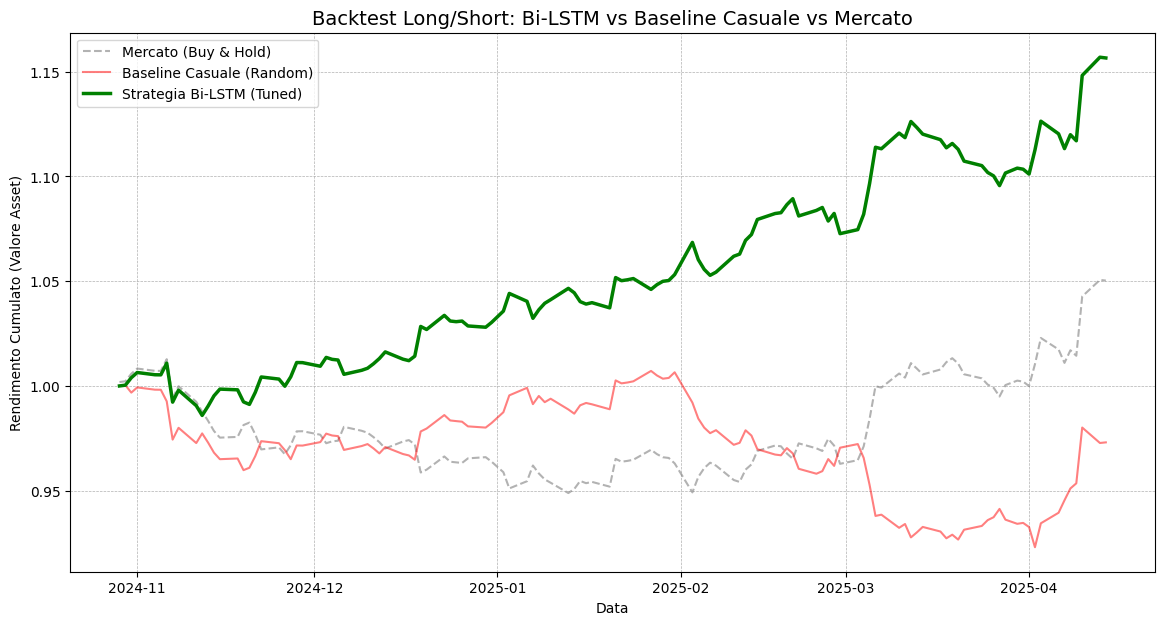

Rendimento Totale Bi-LSTM: 15.66%
Rendimento Totale Casuale: -2.69%
Rendimento Totale Mercato: 5.03%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


y_pred_probs = final_model.predict(X_test_fin)


window_size = best_params['window_size']

test_dates = test_final['Date'].iloc[window_size:].values

test_returns = test_final['Log_Return'].iloc[window_size:].values

backtest_df = pd.DataFrame({
    'Date': test_dates,
    'Actual_Return': test_returns,
    'Prob_Up': y_pred_probs.flatten()
})


soglia_mediana = backtest_df['Prob_Up'].median()
backtest_df['Pos_BiLSTM'] = np.where(backtest_df['Prob_Up'] > soglia_mediana, 1, -1)


backtest_df['Ret_BiLSTM'] = backtest_df['Pos_BiLSTM'].shift(1) * backtest_df['Actual_Return']


np.random.seed(42)
backtest_df['Pos_Random'] = np.random.choice([1, -1], size=len(backtest_df))
backtest_df['Ret_Random'] = backtest_df['Pos_Random'].shift(1) * backtest_df['Actual_Return']


backtest_df['Equity_Market'] = np.exp(backtest_df['Actual_Return'].cumsum())
backtest_df['Equity_BiLSTM'] = np.exp(backtest_df['Ret_BiLSTM'].fillna(0).cumsum())
backtest_df['Equity_Random'] = np.exp(backtest_df['Ret_Random'].fillna(0).cumsum())


plt.figure(figsize=(14, 7))
plt.plot(backtest_df['Date'], backtest_df['Equity_Market'], label='Mercato (Buy & Hold)', color='gray', linestyle='--', alpha=0.6)
plt.plot(backtest_df['Date'], backtest_df['Equity_Random'], label='Baseline Casuale (Random)', color='red', alpha=0.5)
plt.plot(backtest_df['Date'], backtest_df['Equity_BiLSTM'], label='Strategia Bi-LSTM (Tuned)', color='green', linewidth=2.5)

plt.title('Backtest Long/Short: Bi-LSTM vs Baseline Casuale vs Mercato', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Rendimento Cumulato (Valore Asset)')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


perf_bilstm = (backtest_df['Equity_BiLSTM'].iloc[-1] - 1) * 100
perf_random = (backtest_df['Equity_Random'].iloc[-1] - 1) * 100
perf_market = (backtest_df['Equity_Market'].iloc[-1] - 1) * 100

print(f"Rendimento Totale Bi-LSTM: {perf_bilstm:.2f}%")
print(f"Rendimento Totale Casuale: {perf_random:.2f}%")
print(f"Rendimento Totale Mercato: {perf_market:.2f}%")


--- TABELLA RIASSUNTIVA DELLE PERFORMANCE (LOG-RETURN BASED) ---
                     Rendimento Totale (%)  Sharpe Ratio  Max Drawdown (%)
Bi-LSTM (Tuned)                      15.66          3.34             -2.72
Mercato (Benchmark)                   5.03          1.10             -6.31
Casuale (Baseline)                   -2.69         -0.61             -8.36


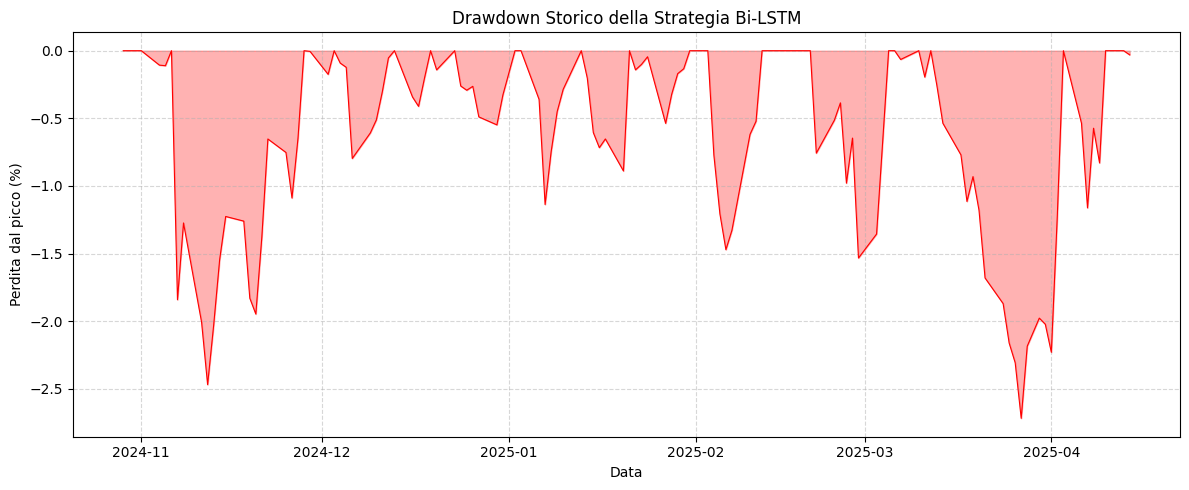

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_metrics(log_returns, name="Strategia"):

    total_return = (np.exp(np.sum(log_returns)) - 1) * 100


    avg_return = np.mean(log_returns)
    std_return = np.std(log_returns)

    if std_return != 0:

        sharpe = (avg_return / std_return) * np.sqrt(252)
    else:
        sharpe = 0


    cumulative = np.exp(np.cumsum(log_returns))
    peak = np.maximum.accumulate(cumulative)

    drawdown = (cumulative - peak) / np.where(peak == 0, 1, peak)
    max_drawdown = np.min(drawdown) * 100

    return {
        "Rendimento Totale (%)": round(total_return, 2),
        "Sharpe Ratio": round(sharpe, 2),
        "Max Drawdown (%)": round(max_drawdown, 2)
    }


metrics_bilstm = calculate_metrics(backtest_df['Ret_BiLSTM'].fillna(0), "Bi-LSTM")
metrics_market = calculate_metrics(backtest_df['Actual_Return'], "Mercato")
metrics_random = calculate_metrics(backtest_df['Ret_Random'].fillna(0), "Casuale")


summary_table = pd.DataFrame([metrics_bilstm, metrics_market, metrics_random],
                             index=['Bi-LSTM (Tuned)', 'Mercato (Benchmark)', 'Casuale (Baseline)'])

print("\n--- TABELLA RIASSUNTIVA DELLE PERFORMANCE (LOG-RETURN BASED) ---")
print(summary_table)


plt.figure(figsize=(12, 5))

cumulative_bilstm = np.exp(np.cumsum(backtest_df['Ret_BiLSTM'].fillna(0)))
peak_bilstm = np.maximum.accumulate(cumulative_bilstm)
drawdown_bilstm = (cumulative_bilstm - peak_bilstm) / np.where(peak_bilstm == 0, 1, peak_bilstm)

plt.fill_between(backtest_df['Date'], drawdown_bilstm * 100, 0, color='red', alpha=0.3)
plt.plot(backtest_df['Date'], drawdown_bilstm * 100, color='red', linewidth=0.8)

plt.title('Drawdown Storico della Strategia Bi-LSTM', fontsize=12)
plt.ylabel('Perdita dal picco (%)')
plt.xlabel('Data')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


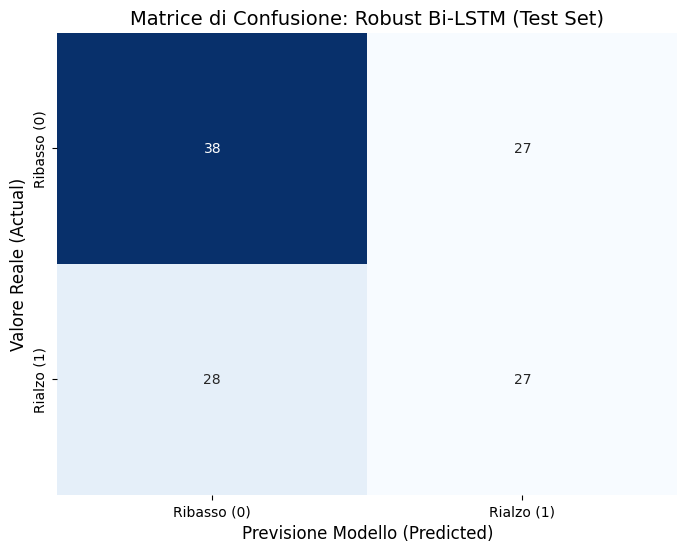


--- REPORT DI CLASSIFICAZIONE ---
              precision    recall  f1-score   support

 Ribasso (0)       0.58      0.58      0.58        65
  Rialzo (1)       0.50      0.49      0.50        55

    accuracy                           0.54       120
   macro avg       0.54      0.54      0.54       120
weighted avg       0.54      0.54      0.54       120



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


y_pred_probs = final_model.predict(X_test_fin)
y_pred = (y_pred_probs > 0.5).astype(int)


cm = confusion_matrix(y_test_fin, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ribasso (0)', 'Rialzo (1)'],
            yticklabels=['Ribasso (0)', 'Rialzo (1)'],
            cbar=False)

plt.xlabel('Previsione Modello (Predicted)', fontsize=12)
plt.ylabel('Valore Reale (Actual)', fontsize=12)
plt.title('Matrice di Confusione: Robust Bi-LSTM (Test Set)', fontsize=14)
plt.show()


print("\n--- REPORT DI CLASSIFICAZIONE ---")
print(classification_report(y_test_fin, y_pred, target_names=['Ribasso (0)', 'Rialzo (1)']))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
AUC Score: 0.5871
Soglia Ottimale calcolata (Youden): 0.4938


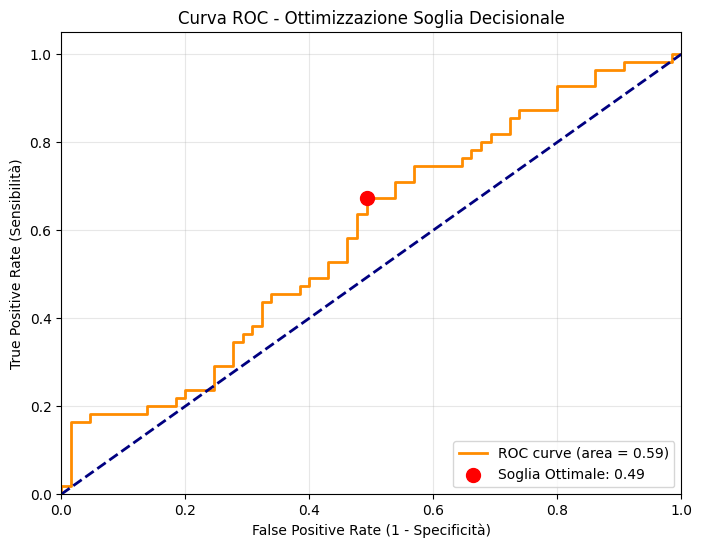

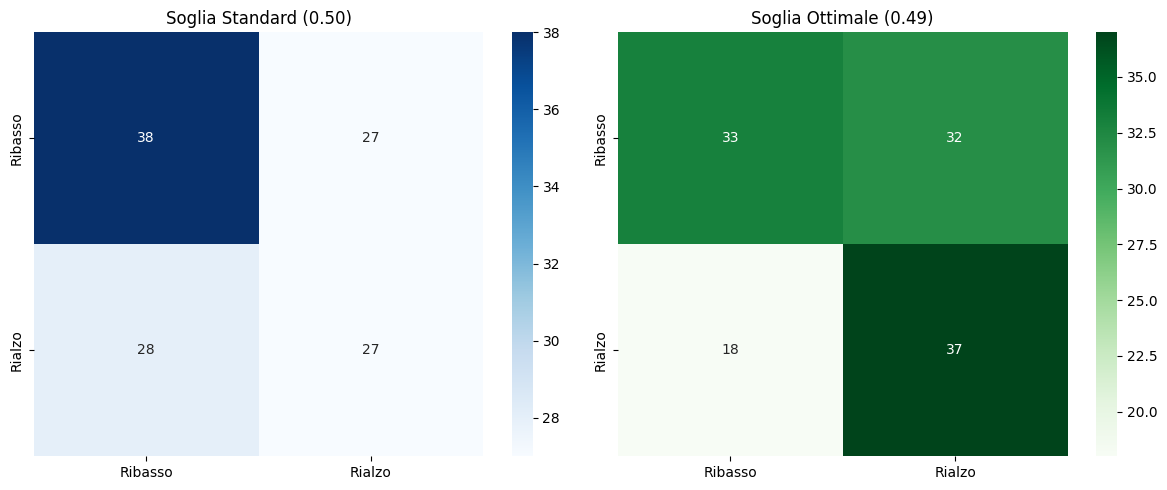


--- REPORT CON SOGLIA OTTIMIZZATA ---
              precision    recall  f1-score   support

 Ribasso (0)       0.65      0.51      0.57        65
  Rialzo (1)       0.54      0.67      0.60        55

    accuracy                           0.58       120
   macro avg       0.59      0.59      0.58       120
weighted avg       0.60      0.58      0.58       120

Brier Score: 0.2469


In [ ]:
from sklearn.metrics import roc_curve, auc, brier_score_loss, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


y_probs = final_model.predict(X_test_fin).ravel()
fpr, tpr, thresholds = roc_curve(y_test_fin, y_probs)
roc_auc = auc(fpr, tpr)


optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"AUC Score: {roc_auc:.4f}")
print(f"Soglia Ottimale calcolata (Youden): {optimal_threshold:.4f}")


plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100,
            label=f'Soglia Ottimale: {optimal_threshold:.2f}', zorder=5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificità)')
plt.ylabel('True Positive Rate (Sensibilità)')
plt.title('Curva ROC - Ottimizzazione Soglia Decisionale')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


y_pred_std = (y_probs >= 0.5).astype(int)
y_pred_opt = (y_probs >= optimal_threshold).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))


sns.heatmap(confusion_matrix(y_test_fin, y_pred_std), annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Ribasso', 'Rialzo'], yticklabels=['Ribasso', 'Rialzo'])
ax[0].set_title('Soglia Standard (0.50)')


sns.heatmap(confusion_matrix(y_test_fin, y_pred_opt), annot=True, fmt='d', cmap='Greens', ax=ax[1],
            xticklabels=['Ribasso', 'Rialzo'], yticklabels=['Ribasso', 'Rialzo'])
ax[1].set_title(f'Soglia Ottimale ({optimal_threshold:.2f})')

plt.tight_layout()
plt.show()

print("\n--- REPORT CON SOGLIA OTTIMIZZATA ---")
print(classification_report(y_test_fin, y_pred_opt, target_names=['Ribasso (0)', 'Rialzo (1)']))


bs = brier_score_loss(y_test_fin, y_probs)
print(f"Brier Score: {bs:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


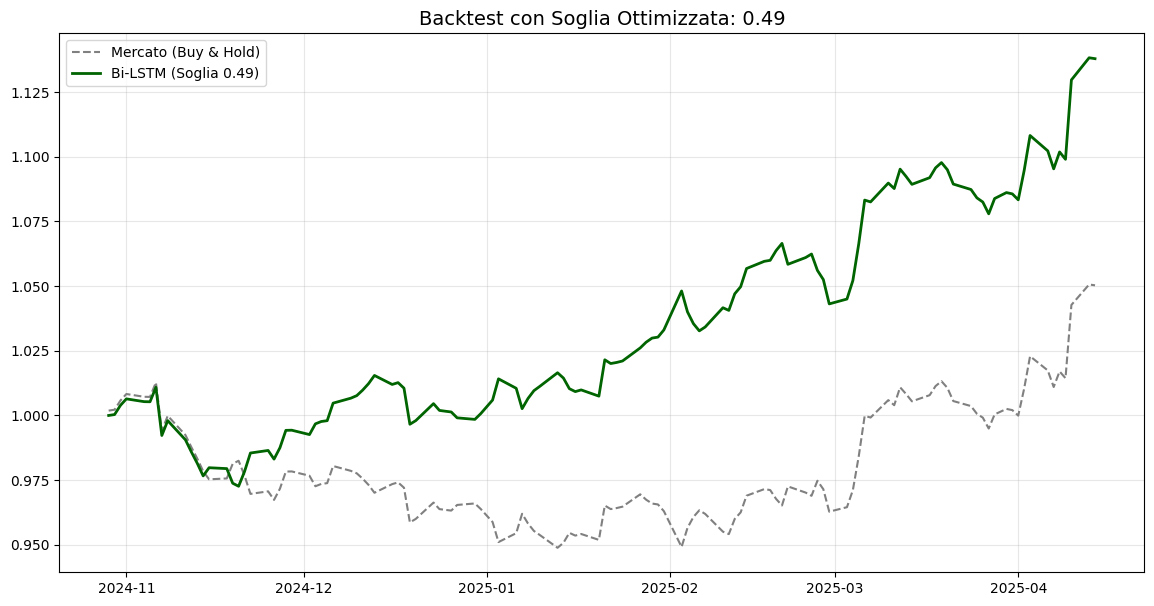

RISULTATI CON SOGLIA 0.49:
Rendimento Totale: 13.79%
Sharpe Ratio: 2.95


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


SOGLIA_CUSTOM = 0.49


y_pred_probs = final_model.predict(X_test_fin)


window_size = best_params['window_size']
test_dates = test_final['Date'].iloc[window_size:].values
test_returns = test_final['Log_Return'].iloc[window_size:].values

backtest_opt_df = pd.DataFrame({
    'Date': test_dates,
    'Actual_Return': test_returns,
    'Prob_Up': y_pred_probs.flatten()
})


backtest_opt_df['Pos_BiLSTM'] = np.where(backtest_opt_df['Prob_Up'] > SOGLIA_CUSTOM, 1, -1)
backtest_opt_df['Ret_BiLSTM'] = backtest_opt_df['Pos_BiLSTM'].shift(1) * backtest_opt_df['Actual_Return']


backtest_opt_df['Equity_Market'] = np.exp(backtest_opt_df['Actual_Return'].cumsum())
backtest_opt_df['Equity_BiLSTM_040'] = np.exp(backtest_opt_df['Ret_BiLSTM'].fillna(0).cumsum())


plt.figure(figsize=(14, 7))
plt.plot(backtest_opt_df['Date'], backtest_opt_df['Equity_Market'], label='Mercato (Buy & Hold)', color='gray', linestyle='--')
plt.plot(backtest_opt_df['Date'], backtest_opt_df['Equity_BiLSTM_040'], label=f'Bi-LSTM (Soglia {SOGLIA_CUSTOM})', color='darkgreen', linewidth=2)

plt.title(f'Backtest con Soglia Ottimizzata: {SOGLIA_CUSTOM}', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


def quick_metrics(log_ret):
    total = (np.exp(np.sum(log_ret)) - 1) * 100
    sharpe = (np.mean(log_ret) / np.std(log_ret)) * np.sqrt(252) if np.std(log_ret) != 0 else 0
    return total, sharpe

perf_040, sharpe_040 = quick_metrics(backtest_opt_df['Ret_BiLSTM'].fillna(0))
print(f"RISULTATI CON SOGLIA {SOGLIA_CUSTOM}:")
print(f"Rendimento Totale: {perf_040:.2f}%")
print(f"Sharpe Ratio: {sharpe_040:.2f}")

In [ ]:
def analyze_trades(df_backtest, name="Strategia"):

    trades = df_backtest['Pos_BiLSTM'].diff().abs().fillna(0).sum() / 2 # /2 perché un cambio +1 a -1 è un'operazione completa


    total_switches = df_backtest['Pos_BiLSTM'].diff().iloc[1:].ne(0).sum()

    print(f"--- Analisi Operatività: {name} ---")
    print(f"Numero totale di inversioni di rotta (Trade): {total_switches}")
    print(f"Media operazioni a settimana: {round(total_switches / (len(df_backtest)/5), 2)}")
    print(f"Permanenza media in una posizione (giorni): {round(len(df_backtest) / (total_switches + 1), 2)}")
    print("-" * 40)
    return total_switches


switches_050 = analyze_trades(backtest_df, "Soglia 0.50 (Standard)")


switches_040 = analyze_trades(backtest_opt_df, "Soglia 0.40 (Ottimizzata)")


diff = switches_040 - switches_050
print(f"\nRisultato: La soglia 0.40 effettua {diff} operazioni in {'più' if diff > 0 else 'meno'} rispetto alla soglia 0.50.")

--- Analisi Operatività: Soglia 0.50 (Standard) ---
Numero totale di inversioni di rotta (Trade): 14
Media operazioni a settimana: 0.58
Permanenza media in una posizione (giorni): 8.0
----------------------------------------
--- Analisi Operatività: Soglia 0.40 (Ottimizzata) ---
Numero totale di inversioni di rotta (Trade): 12
Media operazioni a settimana: 0.5
Permanenza media in una posizione (giorni): 9.23
----------------------------------------

Risultato: La soglia 0.40 effettua -2 operazioni in meno rispetto alla soglia 0.50.


Ultimo Prezzo agganciato (Reale al 15/04/2025): 1.129267
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


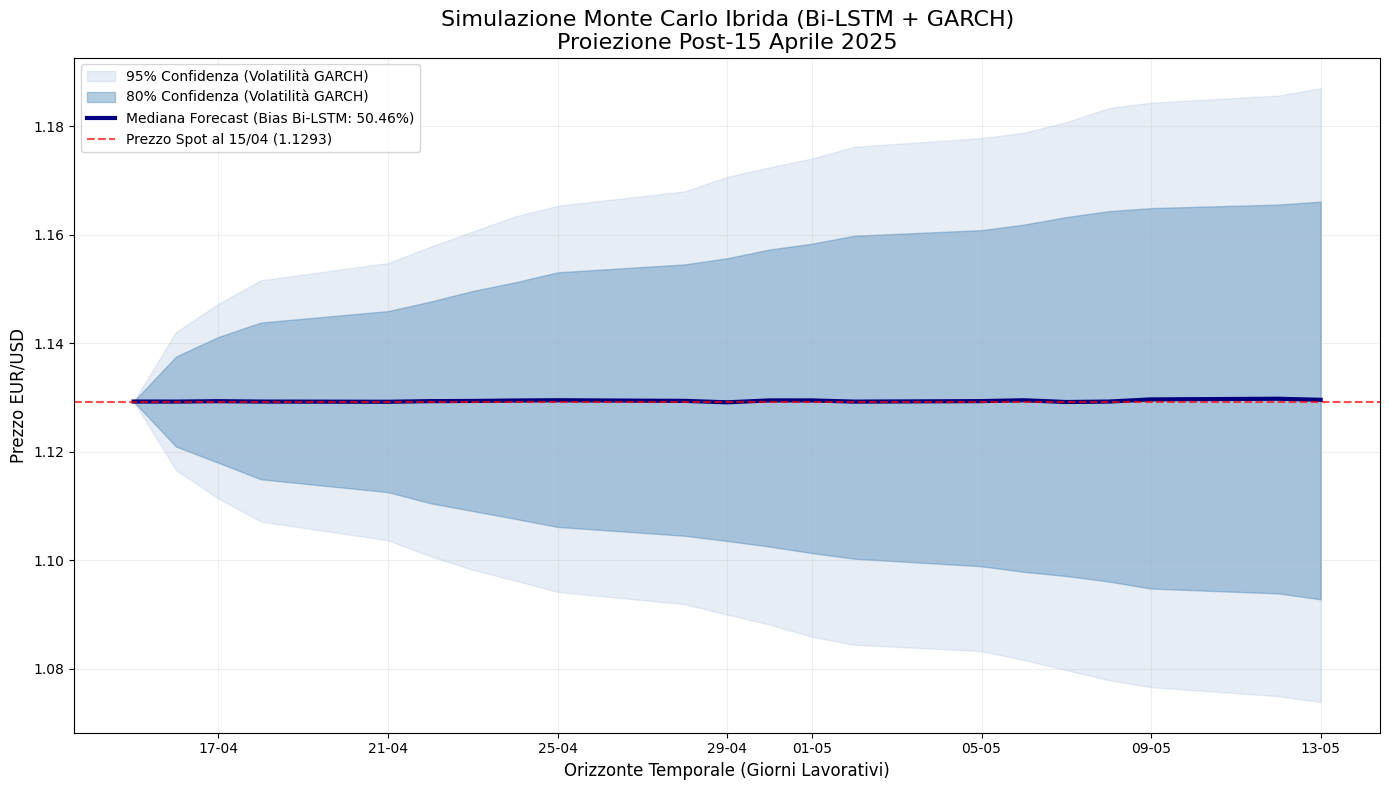

--- RISULTATI ANALISI ---
Probabilità prevista Bi-LSTM per il 16/04: 0.5046
Direzione suggerita: Rialzista
Volatilità attesa (Sigma): 0.005712


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


N_SCENARI = 10000
N_GIORNI_FUTURI = 20
np.random.seed(42)


dati_15_aprile = {
    'Date': pd.to_datetime('2025-04-15'),
    'Prezzo': 1.129267,
    'Sigma': 0.005711679,
    'sent_EUR': 0.02373299,
    'sent_USD': -0.01144999,
    'Log_Return': -0.004152990 # log(1.129267 / 1.133967)
}


df_previsione = df.copy()

df_previsione = pd.concat([df_previsione, pd.DataFrame([dati_15_aprile])], ignore_index=True)


LATEST_PRICE = dati_15_aprile['Prezzo']
LAST_DATE = dati_15_aprile['Date']

print(f"Ultimo Prezzo agganciato (Reale al {LAST_DATE.strftime('%d/%m/%Y')}): {LATEST_PRICE:.6f}")


latest_data_idx = -best_params['window_size']
latest_raw_data = df_previsione[features].iloc[latest_data_idx:].values


latest_scaled_data = final_scaler.transform(latest_raw_data)
latest_sequence = latest_scaled_data.reshape(1, best_params['window_size'], len(features))


predicted_prob = final_model.predict(latest_sequence)[0][0]


latest_sigma = dati_15_aprile['Sigma']


random_returns = np.random.normal(0, latest_sigma, (N_GIORNI_FUTURI, N_SCENARI))


predicted_drift_intensity = (predicted_prob - 0.5) * 2
avg_historical_drift = 0.0005
adjusted_drift = predicted_drift_intensity * avg_historical_drift


simulated_log_returns = random_returns + adjusted_drift
cumulative_log_returns = simulated_log_returns.cumsum(axis=0)
simulated_prices = LATEST_PRICE * np.exp(cumulative_log_returns)


final_sim_prices = np.vstack([np.full(N_SCENARI, LATEST_PRICE), simulated_prices])


median_forecast = np.median(final_sim_prices, axis=1)
lower_80 = np.percentile(final_sim_prices, 10, axis=1)
upper_80 = np.percentile(final_sim_prices, 90, axis=1)
lower_95 = np.percentile(final_sim_prices, 2.5, axis=1)
upper_95 = np.percentile(final_sim_prices, 97.5, axis=1)


future_dates = pd.date_range(start=LAST_DATE, periods=N_GIORNI_FUTURI + 1, freq='B')

plt.figure(figsize=(14, 8))


plt.fill_between(future_dates, lower_95, upper_95, color='#B0C4DE', alpha=0.3, label='95% Confidenza (Volatilità GARCH)')
plt.fill_between(future_dates, lower_80, upper_80, color='#4682B4', alpha=0.4, label='80% Confidenza (Volatilità GARCH)')


plt.plot(future_dates, median_forecast, color='#000080', linewidth=3,
         label=f'Mediana Forecast (Bias Bi-LSTM: {predicted_prob:.2%})')


plt.axhline(y=LATEST_PRICE, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
            label=f'Prezzo Spot al 15/04 ({LATEST_PRICE:.4f})')

plt.title(f'Simulazione Monte Carlo Ibrida (Bi-LSTM + GARCH)\nProiezione Post-15 Aprile 2025', fontsize=16)
plt.ylabel('Prezzo EUR/USD', fontsize=12)
plt.xlabel('Orizzonte Temporale (Giorni Lavorativi)', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
plt.grid(True, alpha=0.2)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

print(f"--- RISULTATI ANALISI ---")
print(f"Probabilità prevista Bi-LSTM per il 16/04: {predicted_prob:.4f}")
print(f"Direzione suggerita: {'Rialzista' if predicted_prob > 0.5 else 'Ribassista'}")
print(f"Volatilità attesa (Sigma): {latest_sigma:.6f}")

/tmp/ipykernel_8059/3308392875.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  real_data = yf.download(ticker, start="2025-04-01", end=END_FORECAST)
[*********************100%***********************]  1 of 1 completed


Punto di aggancio reale (15/04/2025): 1.129267


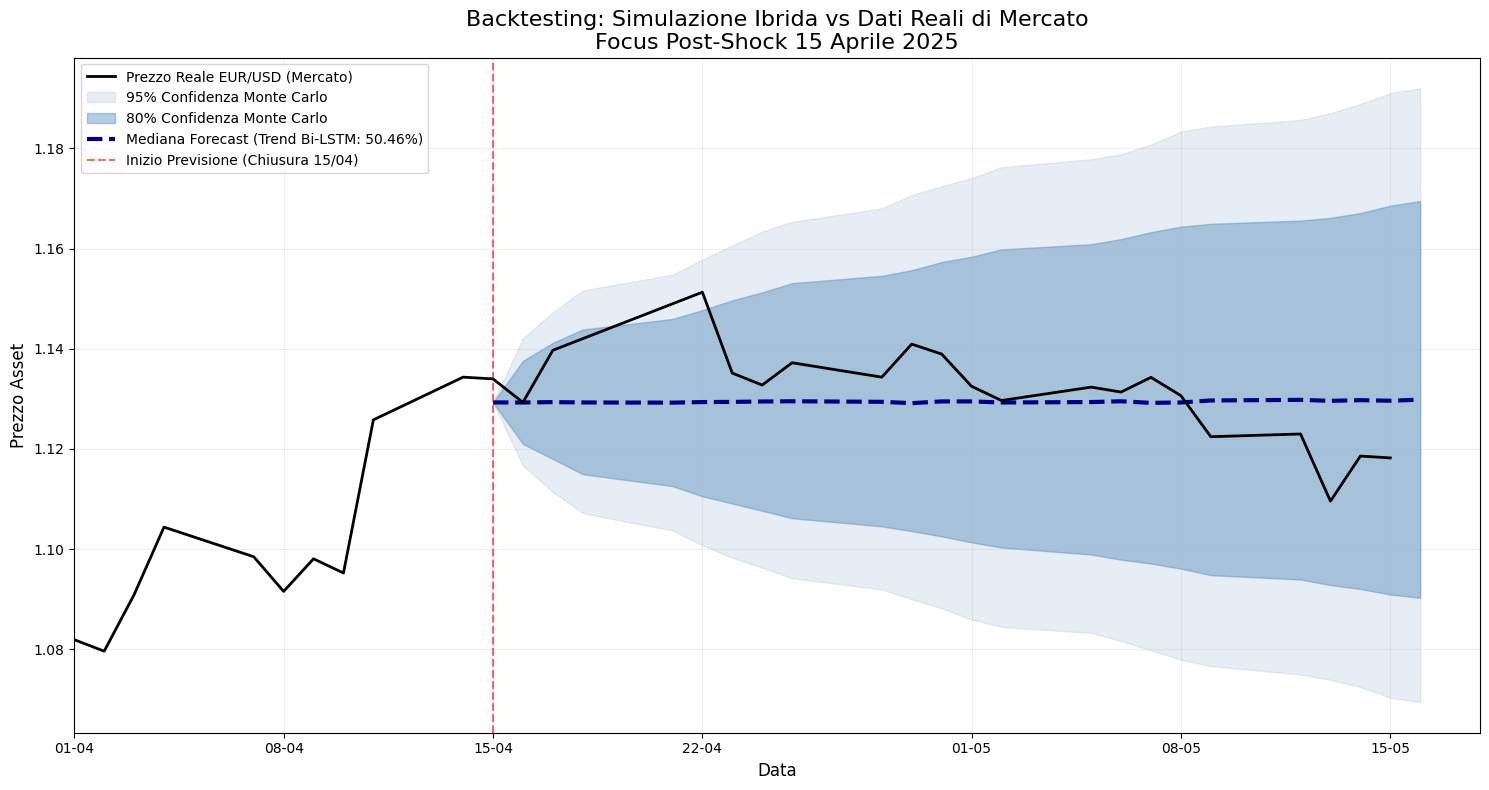

--- REPORT BACKTESTING ---
Probabilità Bi-LSTM (Input 15/04): 0.5046
Prezzo iniziale (15/04): 1.129267
Orizzonte simulato: 23 giorni lavorativi


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf


LAST_HISTORICAL_DATE = "2025-04-15"
START_FORECAST = "2025-04-16"
END_FORECAST = "2025-05-16"


ticker = "EURUSD=X"

real_data = yf.download(ticker, start="2025-04-01", end=END_FORECAST)

if isinstance(real_data.columns, pd.MultiIndex):
    real_data.columns = real_data.columns.get_level_values(0)


LATEST_PRICE = 1.129267
LAST_DATE = pd.to_datetime(LAST_HISTORICAL_DATE)

print(f"Punto di aggancio reale ({LAST_DATE.strftime('%d/%m/%Y')}): {LATEST_PRICE:.6f}")


N_SCENARI = 10000
np.random.seed(42)


latest_sigma = 0.005711679
predicted_prob = 0.5046


future_dates = pd.date_range(start=START_FORECAST, end=END_FORECAST, freq='B')
N_GIORNI_FUTURI = len(future_dates)


random_returns = np.random.normal(0, latest_sigma, (N_GIORNI_FUTURI, N_SCENARI))


predicted_drift_intensity = (predicted_prob - 0.5) * 2
avg_historical_drift = 0.0005
adjusted_drift = predicted_drift_intensity * avg_historical_drift


simulated_log_returns = random_returns + adjusted_drift
cumulative_log_returns = simulated_log_returns.cumsum(axis=0)
simulated_prices = LATEST_PRICE * np.exp(cumulative_log_returns)


final_sim_prices = np.vstack([np.full(N_SCENARI, LATEST_PRICE), simulated_prices])

plot_dates = [LAST_DATE] + list(future_dates)


median_forecast = np.median(final_sim_prices, axis=1)
lower_80 = np.percentile(final_sim_prices, 10, axis=1)
upper_80 = np.percentile(final_sim_prices, 90, axis=1)
lower_95 = np.percentile(final_sim_prices, 2.5, axis=1)
upper_95 = np.percentile(final_sim_prices, 97.5, axis=1)


plt.figure(figsize=(15, 8))


plt.plot(real_data.index, real_data['Close'], color='black', linewidth=2, label='Prezzo Reale EUR/USD (Mercato)', zorder=5)


plt.fill_between(plot_dates, lower_95, upper_95, color='#B0C4DE', alpha=0.3, label='95% Confidenza Monte Carlo')
plt.fill_between(plot_dates, lower_80, upper_80, color='#4682B4', alpha=0.4, label='80% Confidenza Monte Carlo')


plt.plot(plot_dates, median_forecast, color='#000080', linewidth=3, linestyle='--',
         label=f'Mediana Forecast (Trend Bi-LSTM: {predicted_prob:.2%})')


plt.axvline(x=LAST_DATE, color='red', linestyle='--', alpha=0.6, label='Inizio Previsione (Chiusura 15/04)')

plt.title(f'Backtesting: Simulazione Ibrida vs Dati Reali di Mercato\nFocus Post-Shock 15 Aprile 2025', fontsize=16)
plt.ylabel('Prezzo Asset', fontsize=12)
plt.xlabel('Data', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
plt.grid(True, alpha=0.2)
plt.legend(loc='upper left')


plt.xlim(pd.to_datetime("2025-04-01"), pd.to_datetime(END_FORECAST) + pd.Timedelta(days=2))

plt.tight_layout()
plt.show()

print(f"--- REPORT BACKTESTING ---")
print(f"Probabilità Bi-LSTM (Input 15/04): {predicted_prob:.4f}")
print(f"Prezzo iniziale (15/04): {LATEST_PRICE}")
print(f"Orizzonte simulato: {N_GIORNI_FUTURI} giorni lavorativi")

In [ ]:
print(df.tail(1))

          Date    Prezzo     Sigma  Realized  sent_EUR  sent_USD  Log_Return  \
646 2025-04-14  1.133967  0.005861 -0.000306 -0.407379 -0.537141   -0.000306   

     Target  
646       0  
